In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px

from scipy import stats

from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv("../data/BrentOilPrices.csv")

In [3]:
df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   object 
 1   Price   9011 non-null   float64
dtypes: float64(1), object(1)
memory usage: 140.9+ KB


In [5]:
df.describe()

,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


In [6]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

In [19]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")

In [8]:
df = df.sort_values("Date")

In [9]:
print(df.shape)

(9011, 2)


In [10]:
df.columns

Index(['Date', 'Price'], dtype='object')

In [11]:
df.duplicated().sum()

0

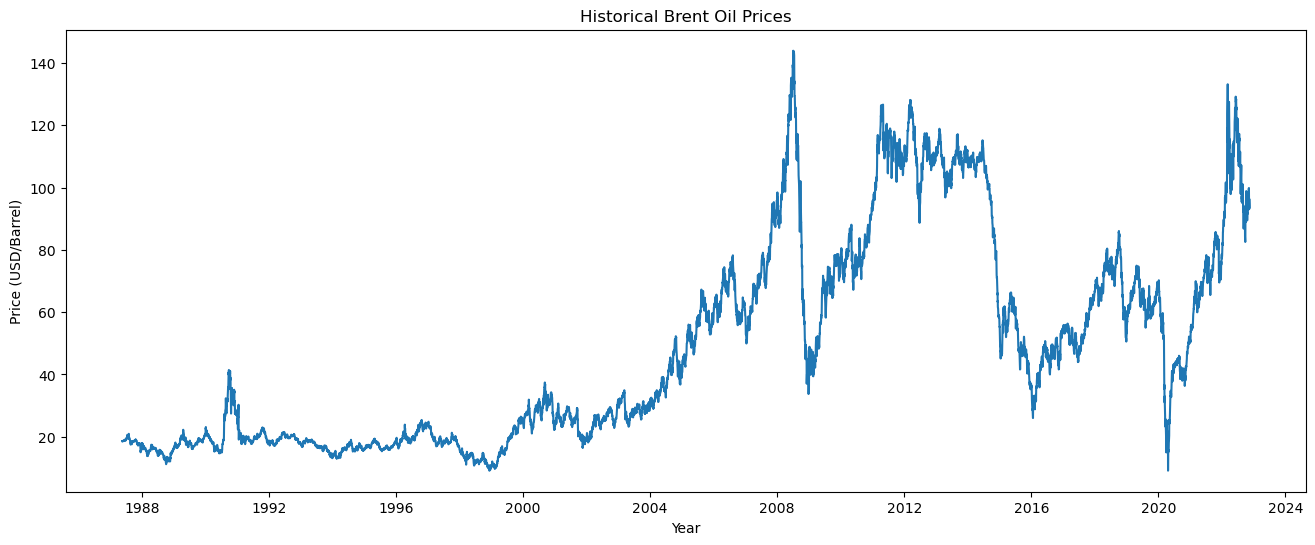

In [12]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"],df["Price"])

plt.title("Historical Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Price (USD/Barrel)")

plt.show()

ADF Test

In [13]:
result = adfuller(df["Price"])

print("ADF Statistic:",result[0])

print("p-value:",result[1])

ADF Statistic: -1.9938560113924688
p-value: 0.28927350489340226


Log Returns

In [14]:
df["Log_Return"] = np.log(df["Price"]).diff()

In [15]:
df = df.dropna()

Text(0.5, 1.0, 'Daily Log Returns')

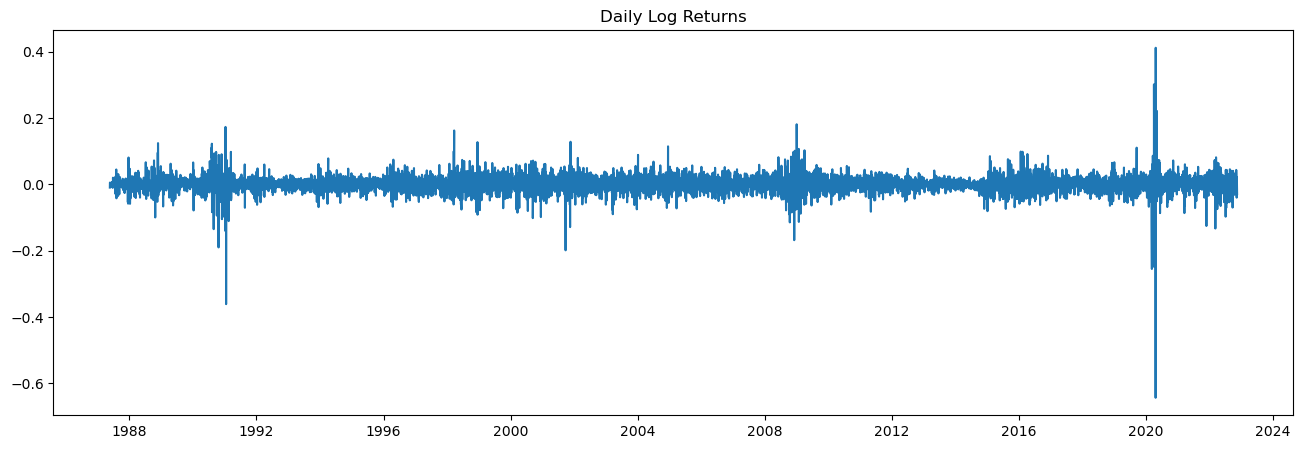

In [16]:
plt.figure(figsize=(16,5))

plt.plot(df["Date"],df["Log_Return"])

plt.title("Daily Log Returns")

In [17]:
result = adfuller(df["Log_Return"])

In [20]:
print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -16.42711349448592
p-value: 2.4985801611427818e-29


Volatility

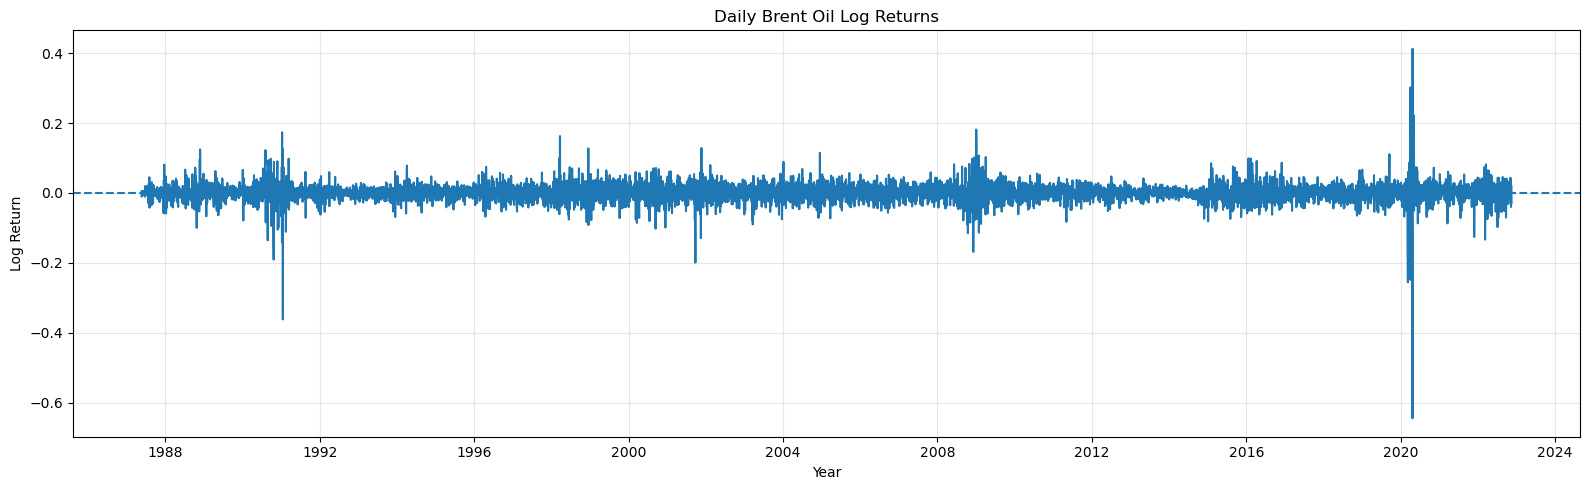

In [21]:
plt.figure(figsize=(16,5))

plt.plot(df["Date"], df["Log_Return"])

plt.axhline(y=0, linestyle="--")

plt.title("Daily Brent Oil Log Returns")

plt.xlabel("Year")

plt.ylabel("Log Return")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Brent oil prices exhibit pronounced long-term fluctuations rather than a steady trend. Several periods of rapid price increases and declines suggest that the market has undergone multiple structural changes, likely associated with major geopolitical and economic events.

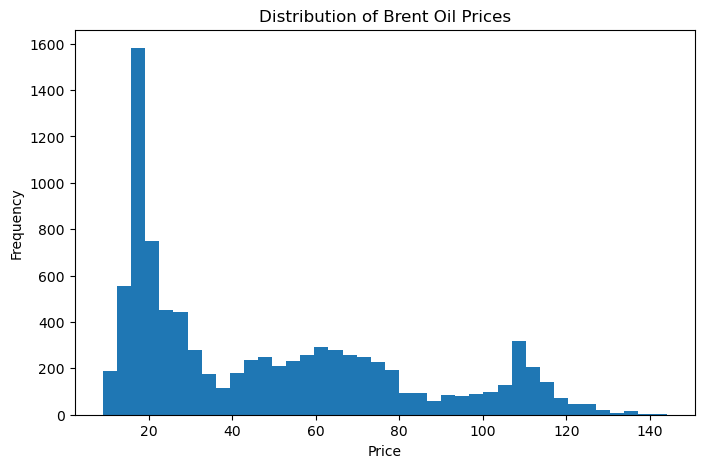

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=40)

plt.title("Distribution of Brent Oil Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

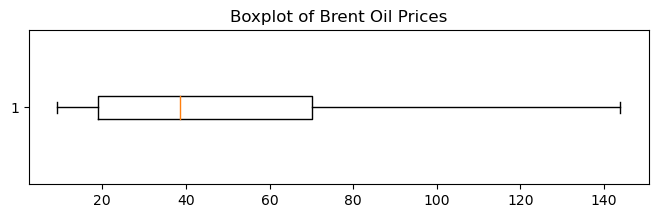

In [23]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Price"], vert=False)

plt.title("Boxplot of Brent Oil Prices")

plt.show()

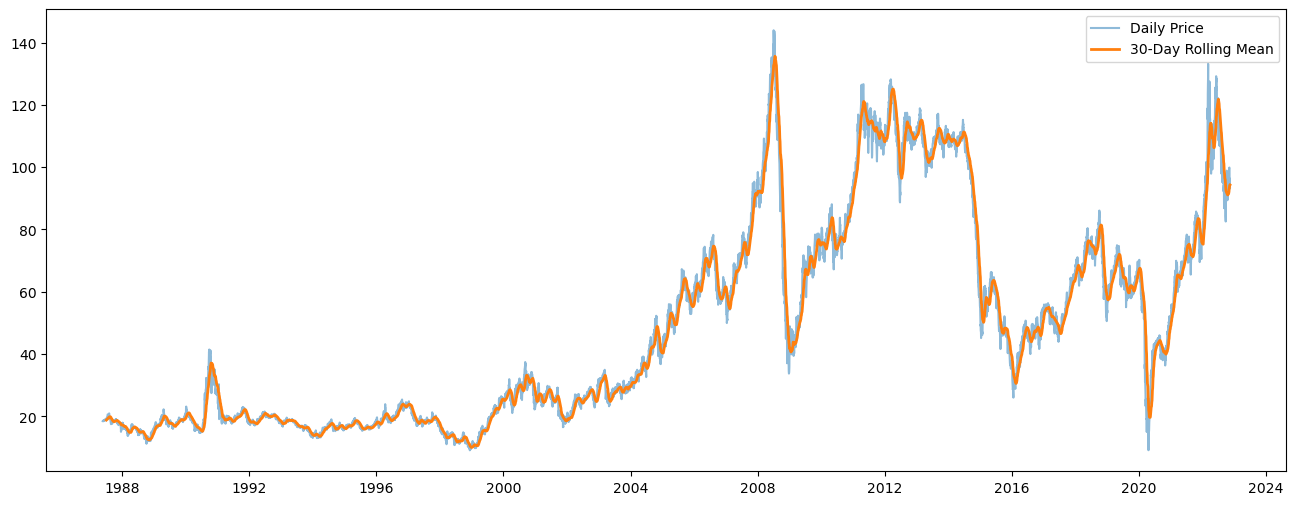

In [24]:
df["Rolling_Mean"] = df["Price"].rolling(window=30).mean()

plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"], alpha=0.5, label="Daily Price")

plt.plot(df["Date"], df["Rolling_Mean"], linewidth=2, label="30-Day Rolling Mean")

plt.legend()

plt.show()